# Puzzle

https://thefiddler.substack.com/p/can-you-win-at-asymmetric-bingo

### This Week’s Fiddler
From Austin Shapiro (and his 7-year-old kid!) comes a two-player game that … might be competitive?

In a game of “asymmetric bingo,” you and your opponent have two differently sized boards: You play on a 5×5 board, while your opponent has an 8×8 board. The 8×8 board has 64 squares, collectively marked with the numbers 1 through 64 in some random arrangement. Meanwhile, the 5×5 board is populated with 25 numbers chosen and arranged randomly (without replacement) from 1 through 64. There are no “free” squares like there are in traditional bingo.

Here’s how the game works: One at a time, a number from 1 to 64 is drawn randomly, without replacement. If that number appears on your 5×5 board, you place a marker on the corresponding square. Otherwise, your opponent (who is guaranteed to have that number somewhere on their board) places the marker on their corresponding square.

The game ends when one of you has “bingo,” meaning five markers in a row going across, down, or diagonally somewhere on the board.

Who is more likely to win this game: you (with the 5×5 board) or your opponent (with the 8×8 board)?

### This Week’s Extra Credit
From Austin also comes the following Extra Credit:

To at least the nearest hundredth, what is the probability that you’ll win a given game of asymmetric bingo?

### Clarifications:

* Simultaneous bingos are not possible in this game. Exactly one player places a marker each turn. (Note the "otherwise" in the puzzle.)

* five numbers in a row must be adjacent — all horizontally, vertically, or diagonally.

# Solution

There are so many things going on, I am really unsure of how they all stack up.

The 5x5 board has 12 bingo streaks (rows, columns, and 2 diagonals).

The 8x8 board has 96 (4 per row * 8 rows = 32, similarly columns = 32, diagonals = 1 + 2 + 3 + 4 + 3 + 2 + 1 = 16 times 2 = 32).

But many of those 96 will be impossible because they use numbers from the 5x5 board. Given that each number has a roughly 40 % chance of being on the 5x5 board, maybe the 96 is reduced to 96 * 0.6^5 ~= 8.

So, now the 8x8 board is worse.

But the numbers coming in are also allocated in a approx 40:60 ratio. So, we need to compare the probability of a streak in the 5x5 board with ~4k markers compared to the 8x8 board with ~6k markers.

Code is needed!!!

But my guess is that the 5x5 board is more likely to win. Let's see.

Some code notes:
In an effort to reduce the time spent doing RNG calls, I'll generate boards and sequences first, and then simulate all cross-products, rather than generating afresh for each trial.
This _should_ also reduce the amount of noise from outliers.
Also, I'll simulate each sequence twice, once in each direction.
This _should_ also further reduce the amount of noise.
But I might be misunderstanding and misapplying ideas from elsewhere. But hopefully, not too badly. 

In [169]:
import random

def get_random_boards(N1, N2, num_boards):
    """
    Generate a list of random N1 x N1 boards.

    Args:
        N1 (int): The size of the board (N1 x N1).
        N2 (int): The size of the board (N2 x N2) to draw values from.
        num_boards (int): The number of random boards to generate.

    Returns:
        list: A list containing num_boards random N x N boards.
    """

    base_list = [x for x in range(1, N2*N2 + 1)]

    boards = []
    for _ in range(num_boards):
        board = random.sample(base_list, N1*N1)
        boards.append(board)
    
    return boards

def create_board_map(N1, board):
    """
    Create a mapping of board values to their (row, col) positions.

    Args:
        N1 (int): The size of the board (N1 x N1).
        board (list): A flat list representing the board values.

    Returns:
        dict: A dictionary mapping each board value to its (row, col) position.
    """
    board_map = {}
    for i in range(N1*N1):
        x, y = divmod(i, N1)
        value = board[i]
        board_map[value] = (x, y)
    return board_map

def get_board_maps(N1, N2, num_boards):
    """
    Generate a list of board maps for each board.

    Args:
        N1 (int): The size of the board (N1 x N1).
        N2 (int): The size of the board (N2 x N2) to draw values from.
        num_boards (int): The number of boards to generate.
    """
    return [create_board_map(N1, board) for board in get_random_boards(N1, N2, num_boards)]

def get_draw_sequences(N1, num_sequences):
    """
    Generate a list of random draw sequences.

    Args:
        N1 (int): The size of the board (N1 x N1).
        num_sequences (int): The number of random draw sequences to generate.

    Returns:
        list: A list containing num_sequences random draw sequences.
    """
    base_list = [x for x in range(1, N1*N1 + 1)]
    sequences = []
    for _ in range(num_sequences//2):
        sequence = random.sample(base_list, N1*N1)
        sequences.append(sequence)
        sequences.append(list(reversed(sequence)))  # Add the reversed sequence as well
    return sequences

print(get_board_maps(2,2,2))
print(get_board_maps(2,3,2))
print(get_draw_sequences(3, 4))
# Looks good.

[{2: (0, 0), 1: (0, 1), 4: (1, 0), 3: (1, 1)}, {2: (0, 0), 3: (0, 1), 4: (1, 0), 1: (1, 1)}]
[{3: (0, 0), 6: (0, 1), 5: (1, 0), 9: (1, 1)}, {2: (0, 0), 7: (0, 1), 6: (1, 0), 3: (1, 1)}]
[[6, 1, 3, 7, 4, 2, 8, 5, 9], [9, 5, 8, 2, 4, 7, 3, 1, 6], [7, 2, 1, 6, 8, 5, 3, 9, 4], [4, 9, 3, 5, 8, 6, 1, 2, 7]]


In [170]:
def check_for_bingo(xy_set, last_x, last_y, N, streak_length):
    """
    Check if a bingo has been achieved on the board.

    Args:
        xy_set (set): A set of (row, col) tuples representing marked positions.
        last_x (int): The x value of the last marked position.
        last_y (int): The y value of the last marked position.
        N (int): The size of the board (N x N).
        streak_length (int): The length of the streak required for bingo.
    """
    # We only need to check the row, column, and diagonals that include the last marked position.

    # Check the row
    for y in [last_y]:
        for x in range(max(last_x - (streak_length - 1), 0), last_x + 1):
            all_present = True
            for i in range(streak_length):
                if (x + i, y) not in xy_set:
                    all_present = False
                    break
            if all_present:
                return True

    # Check the column
    for x in [last_x]:
        for y in range(max(last_y - (streak_length - 1), 0), last_y + 1):
            all_present = True
            for i in range(streak_length):
                if (x, y + i) not in xy_set:
                    all_present = False
                    break
            if all_present:
                return True

    # Check the diagonals
    # Diagonal 1
    for d in range(-streak_length + 1, 1):
        x = last_x + d
        y = last_y + d
        if 0 <= x < N - streak_length + 1 and 0 <= y < N - streak_length + 1:
            all_present = True
            for i in range(streak_length):
                if (x + i, y + i) not in xy_set:
                    all_present = False
                    break
            if all_present:
                return True

    # Diagonal 2
    for d in range(-streak_length + 1, 1):
        x = last_x + d
        y = last_y - d
        if 0 <= x < N - streak_length + 1 and streak_length - 1 <= y < N:
            all_present = True
            for i in range(streak_length):
                if (x + i, y - i) not in xy_set:
                    all_present = False
                    break
            if all_present:
                return True

    return False

assert check_for_bingo(set([(0, 0), (1, 1), (2, 2)]), 2, 2, 5, 3) == True
assert check_for_bingo(set([(0, 0), (1, 1), (2, 2)]), 2, 2, 5, 4) == False

assert check_for_bingo(set([(0, 3), (1, 2), (2, 1), (3, 0)]), 0, 3, 5, 4) == True
assert check_for_bingo(set([(0, 3), (1, 2), (2, 1), (4, 0)]), 0, 3, 5, 4) == False

In [171]:
def play_one_game(board_map_1, board_map_2, draw_sequence, N1=5, N2=8):
    """
    Simulate a game between two boards using a draw sequence.

    Args:
        board_map_1 (dict): The board map for the first board (N1 x N1).
        board_map_2 (dict): The board map for the second board (N2 x N2).
        draw_sequence (list): The sequence of numbers drawn.
        N1 (int): The size of the first board.
        N2 (int): The size of the second board.

    Returns:
        tuple: A tuple containing the winning board and the number of draws taken to win.
    """

    # Initialize sets to track marked positions
    marked_positions_1 = set()
    marked_positions_2 = set()

    for draw_count, number in enumerate(draw_sequence, start=1):
        if number in board_map_1:
            x,y = board_map_1[number]
            marked_positions_1.add((x, y))
            if check_for_bingo(marked_positions_1, x, y, N1, N1):
                return (N1, draw_count)

        else:
            x,y = board_map_2[number]
            marked_positions_2.add((x, y))
            if check_for_bingo(marked_positions_2, x, y, N2, N1):
                return (N2, draw_count)

    assert False, "No board won after all draws were made."

In [172]:
import time
def collect_win_counts(NUM_BOARDS_1=10, NUM_BOARDS_2=10, NUM_SEQUENCES=10, N1=5, N2=8, verbose=False):
    """
    Collect win counts.

    Args:
        NUM_BOARDS_1 (int): The number of N1 x N1 boards to simulate.
        NUM_BOARDS_2 (int): The number of N2 x N2 boards to simulate.
        NUM_SEQUENCES (int): The number of sequences to simulate.
        N1 (int): The size of the first board.
        N2 (int): The size of the second board.
    """
    assert N1 <= N2, "N1 should be less than or equal to N2 for this simulation."

    start_time = time.time()

    board_maps_1 = get_board_maps(N1, N2, NUM_BOARDS_1)
    board_maps_2 = get_board_maps(N2, N2, NUM_BOARDS_2)
    draw_sequences = get_draw_sequences(N2, NUM_SEQUENCES)

    rng_done_time = time.time()

    win_counts_by_draw_count = {}
    win_counts_by_draw_count[N1] = [0] * (N2*N2 + 1)  # Index 0 unused, counts for draws 1 to N2*N2
    win_counts_by_draw_count[N2] = [0] * (N2*N2 + 1)  # Index 0 unused, counts for draws 1 to N2*N2

    for bm1 in board_maps_1:
        for bm2 in board_maps_2:
            for seq in draw_sequences:
                winning_board, draw_count = play_one_game(bm1, bm2, seq, N1, N2)
                win_counts_by_draw_count[winning_board][draw_count] += 1

    win_counts_total = {N1: sum(win_counts_by_draw_count[N1]), N2: sum(win_counts_by_draw_count[N2])}

    end_time = time.time()

    if verbose:
        print(f"Total time: {end_time - start_time} s")
        print(f"RNG setup time: {rng_done_time - start_time} s")
        print(f"Win counts (N1): {win_counts_total[N1]}")
        print(f"Win counts (N2): {win_counts_total[N2]}")
        print(f"Win Probabilities (N1): {win_counts_total[N1] / (NUM_BOARDS_1 * NUM_BOARDS_2 * NUM_SEQUENCES)}")
        print(f"Win Probabilities (N2): {win_counts_total[N2] / (NUM_BOARDS_1 * NUM_BOARDS_2 * NUM_SEQUENCES)}")

    return win_counts_total, win_counts_by_draw_count

In [173]:
wct, wcdc = collect_win_counts(NUM_BOARDS_1=200, NUM_BOARDS_2=200, NUM_SEQUENCES=200, N1=5, N2=8, verbose=True)

Total time: 919.307235956192 s
RNG setup time: 0.006203889846801758 s
Win counts (N1): 5324408
Win counts (N2): 2675592
Win Probabilities (N1): 0.665551
Win Probabilities (N2): 0.334449


The numbers seems stable across multiple runs. The 5x5 board wins with probability around 0.66+something and the 8x8 board wins with probability 0.33 + something. Likely it is exactly 2/3 and 1/3, but that's not certain yet.

In [174]:
# Find the most likely and average draw counts.

most_likely_draw, most_likely_draw_count = None, 0
weighted_draw_sum, total_draw_count = 0, 0
for draw in range(1, 65):
    count_for_draw = wcdc[5][draw] + wcdc[8][draw]
    if count_for_draw > most_likely_draw_count:
        most_likely_draw_count = count_for_draw
        most_likely_draw = draw
    weighted_draw_sum += count_for_draw * draw
    total_draw_count += count_for_draw

if total_draw_count > 0:
    average_draws = weighted_draw_sum / total_draw_count
else:
    average_draws = 0

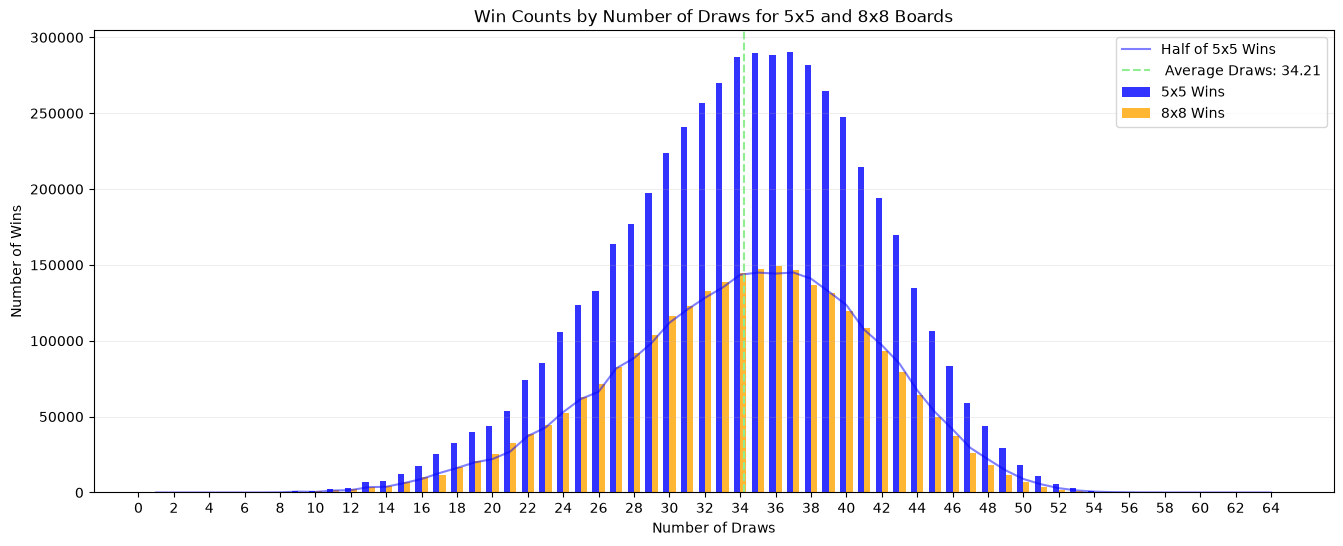

In [182]:
# Generate a paired histogram to visualize the win counts for N1 and N2 across the number of draws.

import matplotlib.pyplot as plt

bins = range(1, 65)  # Draw counts from 1 to 64

bar_width = 0.35

plt.figure(figsize=(16, 6))
plt.bar([b - bar_width/2 for b in bins], wcdc[5][1:], width=bar_width, label='5x5 Wins', color='blue', alpha=0.8)
plt.bar([b + bar_width/2 for b in bins], wcdc[8][1:], width=bar_width, label='8x8 Wins', color='orange', alpha=0.8)
plt.plot([b for b in bins], [y/2  for y in wcdc[5][1:]], color='blue', alpha=0.5, label='Half of 5x5 Wins', linestyle='-')

plt.xlabel('Number of Draws')
plt.ylabel('Number of Wins')
plt.title('Win Counts by Number of Draws for 5x5 and 8x8 Boards')
#plt.axvline(x=most_likely_draw, color='lightblue', linestyle='--', label=f' Most Likely Draw: {most_likely_draw}')
plt.axvline(x=average_draws, color='lightgreen', linestyle='--', label=f' Average Draws: {average_draws:.2f}')
plt.xticks(range(0, 65, 2))  # Show every second tick for clarity
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.show()

The close agreement between the blue curve (half of the 5x5 wins) and the orange bars (8x8 wins) shows that the 2:1 ratio for 5x5:8x8 is maintained across the full range, rather than being only an aggregate effect. i.e. it's not like 5x5 tends to win more early, and 8x8 tends to win more late, and it averages out to a 2:1 ratio.

The mystery of why there is a 2:1 ratio remains.

# Digression : Different board sizes.

Let's see how the situation evolves with different board sizes.

In [176]:
MAX_BOARD_SIZE = 20
probabilities_2D = {}
for N1 in range(1, MAX_BOARD_SIZE + 1):
    for N2 in range(N1, MAX_BOARD_SIZE + 1):
        scale_factor = int(5 + (25/(1 + abs(N2/2 - N1))))  # fewer simulations for larger differences in board sizes, where the data is more skewed and less interesting.
        win_counts, _ = collect_win_counts(NUM_BOARDS_1=scale_factor, NUM_BOARDS_2=scale_factor, NUM_SEQUENCES=scale_factor, N1=N1, N2=N2, verbose=False)
        N1_prob = win_counts[N1] / (scale_factor * scale_factor * scale_factor)  # Total games played
        probabilities_2D[(N1, N2)] = N1_prob

Win Probability for N1=3, N2=5: 0.4092. Diff from 0.5: 0.0908
Win Probability for N1=4, N2=7: 0.4030. Diff from 0.5: 0.0970
Win Probability for N1=5, N2=9: 0.4145. Diff from 0.5: 0.0855
Win Probability for N1=6, N2=11: 0.4636. Diff from 0.5: 0.0364
Win Probability for N1=7, N2=13: 0.4571. Diff from 0.5: 0.0429
Win Probability for N1=8, N2=16: 0.4104. Diff from 0.5: 0.0896
Win Probability for N1=9, N2=18: 0.4557. Diff from 0.5: 0.0443


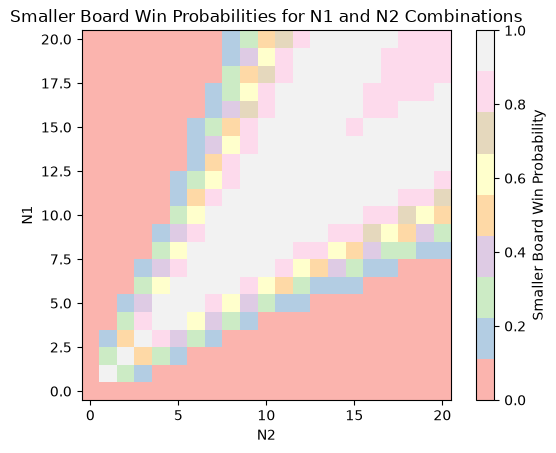

In [177]:
# Generate a 2D heatmap to visualize the win probabilities for N1 and N2 combinations.

import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array to hold the probabilities
heatmap_data = np.zeros((MAX_BOARD_SIZE + 1, MAX_BOARD_SIZE + 1))
for (N1, N2), prob in probabilities_2D.items():
    heatmap_data[N1, N2] = prob
    heatmap_data[N2, N1] = prob  # Fill the symmetric value
    if 0.4 <= prob <= 0.5:  # Highlight probabilities around 0.5
        print(f"Win Probability for N1={N1}, N2={N2}: {prob:.4f}. Diff from 0.5: {abs(prob - 0.5):.4f}")

# Plot the heatmap
plt.imshow(heatmap_data, cmap='Pastel1', origin='lower')
plt.colorbar(label='Smaller Board Win Probability')
plt.xlabel('N2')
plt.ylabel('N1')
plt.title('Smaller Board Win Probabilities for N1 and N2 Combinations')
plt.show()

While the data is noisy, esp because of my scaling the number of simulations, the trend is clear. Switching the original game from 5x5 vs 8x8 to 5x5 vs 9x9 would make the game a lot fairer already. 7x7 vs 13x13 seems to be the fairest out of the ones I looked at.

# Possible Streak Count

An idea about the original situation.

Before any draws, one can count up all possible streaks on the two boards. The 5x5 always has 12 possible streaks. The 8x8 will have some number of streaks possible (0 to 96, I think).
At that point, one can transform each board into just a list of streaks. There is some overlap between streaks in each board, but it is not much. So, each board's win probability is roughly proportional to the number of possible streaks on that board. So, if we can show that the expected number of streaks on the 8x8 board is 6, it would give some further support to the 2:1 case.

This should be easier to measure since only one board is involved (w.l.o.g. we can assume that the 5x5 has numbers 1 to 25), and no sequence needs to be generated.

In [178]:
def count_possible_streaks_in_board(board, N1=5, N2=8):
    """
    Count the number of possible winning streaks on a given board.

    Args:
        board (list): A flat list representing the board values.
        N1 (int): The size of the first board (N1 x N1).
        N2 (int): The size of the second board (N2 x N2).

    Returns:
        int: The total number of possible winning streaks on the board.
    """
    N1_sq = N1 * N1
    board_2d = [board[i * N2:(i + 1) * N2] for i in range(N2)]
    #print(f"Board:\n{board_2d}")

    count = 0
    # Check rows
    for y in range(N2):
        for x in range(N2 - N1 + 1):
            all_valid = True
            for k in range(N1):
                #print(f"Checking row: y={y}, x={x}, k={k}")
                if board_2d[y][x + k] <= N1_sq:
                    all_valid = False
                    break
            if all_valid:
                count += 1

    # Check columns
    for x in range(N2):
        for y in range(N2 - N1 + 1):
            all_valid = True
            for k in range(N1):
                if board_2d[y + k][x] <= N1_sq:
                    all_valid = False
                    break
            if all_valid:
                count += 1

    # Check diagonals 1
    for y in range(N2 - N1 + 1):
        for x in range(N2 - N1 + 1):
            all_valid = True
            for k in range(N1):
                if board_2d[y + k][x + k] <= N1_sq:
                    all_valid = False
                    break
            if all_valid:
                count += 1

    # Check diagonals 2
    for y in range(N1 - 1, N2):
        for x in range(N2 - N1 + 1):
            all_valid = True
            for k in range(N1):
                if board_2d[y - k][x + k] <= N1_sq:
                    all_valid = False
                    break
            if all_valid:
                count += 1
    
    return count

count_possible_streaks_in_board(get_random_boards(8, 8, 1)[0], N1=5, N2=8)

6

In [179]:
def collect_possible_streak_counts(NUM_BOARDS=10000, N1=5, N2=8, verbose=False):
    """
    Collect win counts.

    Args:
        NUM_BOARDS_1 (int): The number of N1 x N1 boards to simulate.
        NUM_BOARDS_2 (int): The number of N2 x N2 boards to simulate.
        NUM_SEQUENCES (int): The number of sequences to simulate.
        N1 (int): The size of the first board.
        N2 (int): The size of the second board.
    """
    assert N1 <= N2, "N1 should be less than or equal to N2 for this simulation."

    start_time = time.time()

    boards = get_random_boards(N2, N2, NUM_BOARDS)

    rng_done_time = time.time()

    max_streak_count = 2*N2*(N2 - N1 + 1)  + 2*(N2 - N1 + 1)*(N2 - N1 + 1)  # Rows + Columns + Diagonals

    streak_counts = [0 for _ in range(max_streak_count + 1)] 

    for board in boards:
        streak_count = count_possible_streaks_in_board(board, N1, N2)
        streak_counts[streak_count] += 1

    weighted_streak_sum = sum(count * streak for streak, count in enumerate(streak_counts))
    total_streak_count = sum(streak_counts)
    average_streaks = weighted_streak_sum / total_streak_count if total_streak_count > 0 else 0

    end_time = time.time()

    if verbose:
        print(f"Total time: {end_time - start_time} s")
        print(f"RNG setup time: {rng_done_time - start_time} s")
        print(f"Average Streaks: {average_streaks}")

    return average_streaks, streak_counts

In [180]:
average_streaks, streak_counts = collect_possible_streak_counts(NUM_BOARDS=1000000, N1=5, N2=8, verbose=True)

Total time: 24.577861309051514 s
RNG setup time: 9.871464729309082 s
Average Streaks: 7.246458


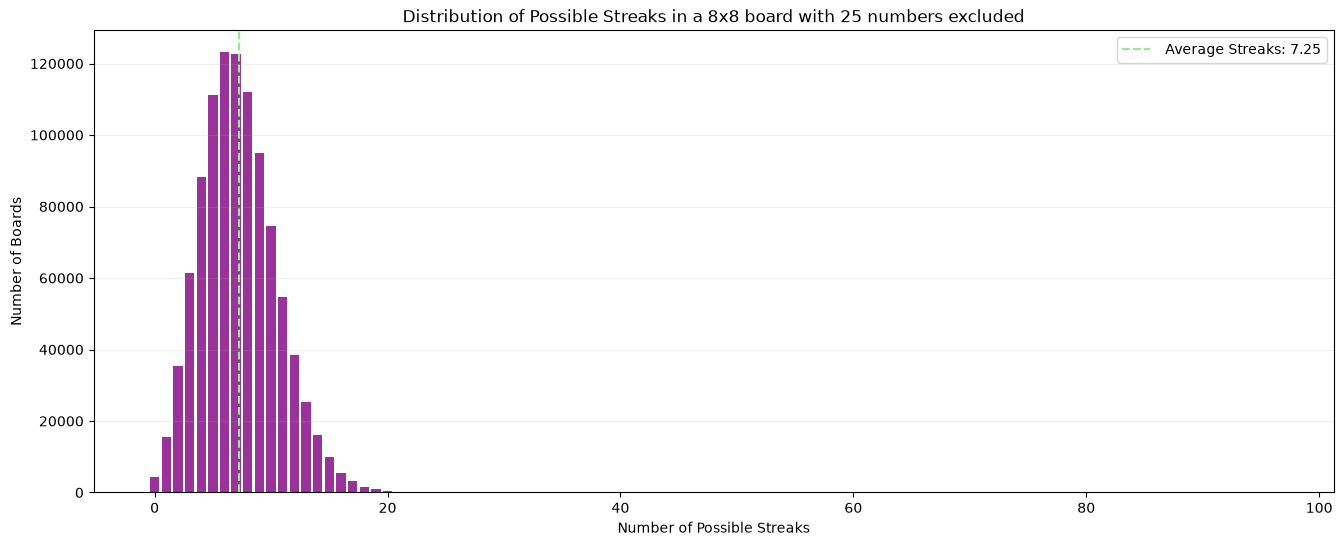

In [181]:
# Plot the histogram of possible streak counts.

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
plt.bar(range(len(streak_counts)), streak_counts, color='purple', alpha=0.8)
plt.xlabel('Number of Possible Streaks')
plt.ylabel('Number of Boards')
plt.title('Distribution of Possible Streaks in a 8x8 board with 25 numbers excluded')
plt.axvline(x=average_streaks, color='lightgreen', linestyle='--', label=f' Average Streaks: {average_streaks:.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.show()

Okay, so it is not a tidy 6. It is 7.24. Not sure what to make of this.

# Conclusion.

Fiddler Answer: **The 5x5 board is more likely to win.**

Extra Credit Answer: **The probability of the 5x5 board winning is 0.666.**

Also: While the data is noisy, the trend seems clearer. Switching the original game from 5x5 vs 8x8 to **5x5 vs 9x9** would make the game a lot fairer than it is. **7x7 vs 13x13** seems to be the fairest out of the ones I looked at (up to 20x20).